# **Project Name** - Brain MRI Tumor Classification using CNN


# **Project Summary -**


In [1]:
project_type = "Image Classification / Deep Learning"
contribution = "Individual"


##### **Project Type** - Image Classification / Deep Learning
##### **Contribution** - Individual
##### **Team Member 1** - Yash Jaiswal


This project develops a Deep Learning system for classifying brain MRI images into the tumor classes present in the dataset. The images are organized into training, validation, and testing folders, with each class represented by a directory name. TensorFlow and Keras are used to load the images, resize them to 320×320 pixels, batch them, preprocess pixel values, and train Convolutional Neural Network (CNN) models. The project begins with exploratory analysis of class distribution, dataset splits, sample images, duplicate files, empty files, image dimensions, and simple image-intensity statistics.

A CNN is suitable for this problem because it can automatically learn spatial features from images. Early convolutional layers learn simple patterns such as edges and textures, while deeper layers learn more complex shapes and structures. The workflow therefore moves from data understanding and image preprocessing to CNN model development, evaluation, comparison, and saving the best model for future deployment. Data augmentation and dropout are used in improved models to reduce overfitting and improve generalization.

Because this is an image dataset, many traditional tabular-data operations are not directly applicable. There is no need for ordinary numerical missing-value imputation, categorical encoding of input columns, text preprocessing, or conventional IQR-based outlier removal. Instead, image-specific operations such as resizing, pixel normalization, augmentation, and class weighting are considered. Class weights can be used when some classes contain fewer images than others so that the model does not become biased toward the majority class.

Multiple CNN configurations are compared using accuracy, precision, recall, F1-score, and confusion matrices. The final model is selected using unseen test performance and generalization rather than training accuracy alone. Early stopping is used to reduce unnecessary training when validation loss stops improving. The selected model is saved in Keras format and loaded again for a sanity-check prediction on unseen test images.

This project is an important step toward Deep Learning because it combines image preprocessing, convolution, pooling, activation functions, dropout, optimization, evaluation, and model deployment in one practical application. Future improvements can include transfer learning, Grad-CAM explainability, more systematic hyperparameter tuning, and a Streamlit interface for user interaction.


# **GitHub Link -**


Add your GitHub repository link here.


# **Problem Statement**


Develop a Deep Learning image classification system that analyzes brain MRI images and classifies them into the tumor categories present in the dataset. The system should perform appropriate image exploration and preprocessing, train CNN models, evaluate their performance, compare models, select the best model, and save it for future prediction and deployment.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf 
from scipy import stats


### Dataset Loading

In [3]:
# Load Dataset. 
train_dir = "train"
valid_dir = "valid"
test_dir = "test"

IMG_SIZE = (320, 320)
BATCH_SIZE = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 1695 files belonging to 4 classes.
Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.


### Dataset First View

Classes:  ['glioma', 'meningioma', 'no_tumor', 'pituitary']
number of classes:  4
Training batches: 53
Validation batches: 16
Testing batches: 8


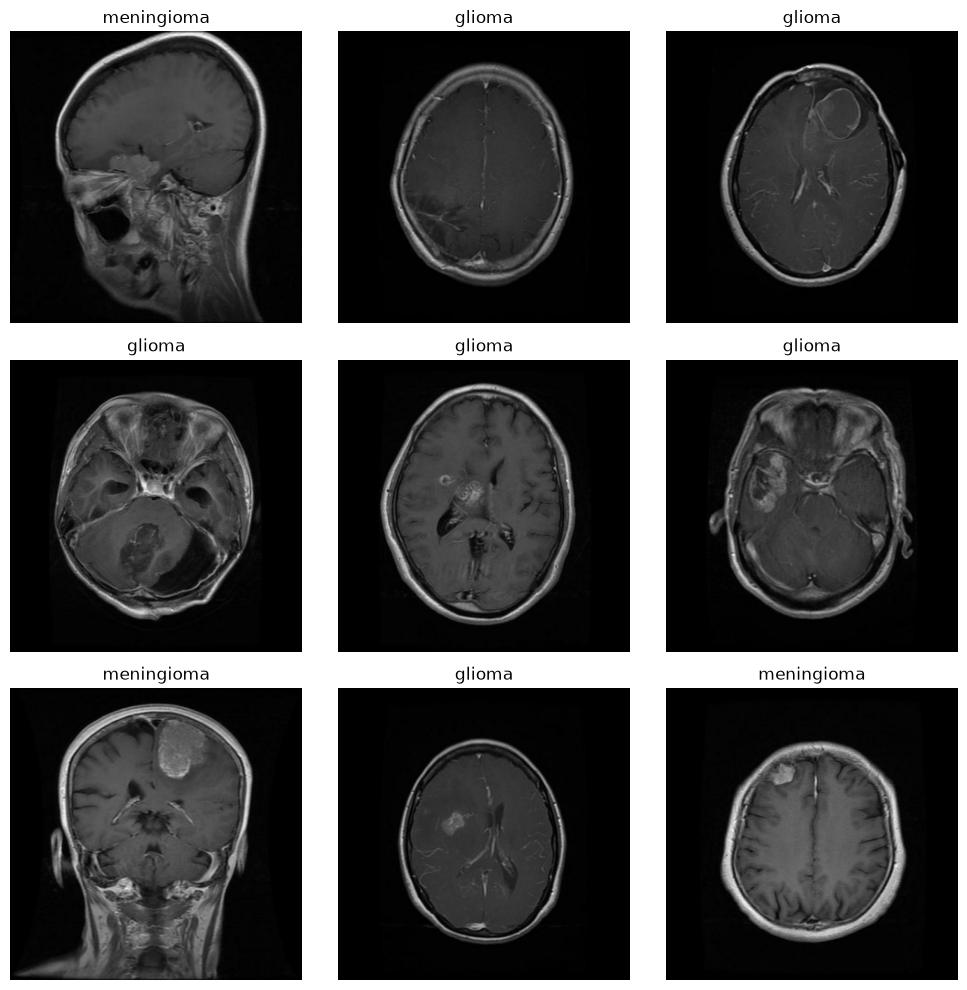

In [4]:
# Dataset First Look 
classm=train_ds.class_names
print("Classes: ",classm)
print("number of classes: ",len(classm))
print("Training batches:", len(train_ds))
print("Validation batches:", len(valid_ds))
print("Testing batches:", len(test_ds))
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classm[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
import os

for folder in ["train", "valid", "test"]:
    print("\n", folder)

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(class_name, ":", count)


 train
pituitary : 438
no_tumor : 335
glioma : 564
meningioma : 358

 valid
pituitary : 118
no_tumor : 99
glioma : 161
meningioma : 124

 test
pituitary : 54
no_tumor : 49
glioma : 80
meningioma : 63


### Dataset Information

In [6]:
# Dataset Info
import os

for folder in ["train", "valid", "test"]:
    print("\n", folder)

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(class_name, ":", count)


 train
pituitary : 438
no_tumor : 335
glioma : 564
meningioma : 358

 valid
pituitary : 118
no_tumor : 99
glioma : 161
meningioma : 124

 test
pituitary : 54
no_tumor : 49
glioma : 80
meningioma : 63


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count. 
import os
import pandas as pd
TRAIN_DIR = "train"
TEST_DIR = "test"
VALID_DIR = "valid"
records = []

for folder in [TRAIN_DIR, VALID_DIR, TEST_DIR]:

    for root, folders, files in os.walk(folder):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

                path = os.path.join(root, file)

                with open(path, "rb") as f:
                    content = f.read()

                records.append((path, content))

df = pd.DataFrame(records, columns=["Path", "Content"])

duplicate_count = df.duplicated("Content").sum()

print("Number of duplicate images:", duplicate_count)



Number of duplicate images: 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
import os

for folder in ["train", "valid", "test"]:

    print("\nChecking:", folder)

    empty_files = 0

    for root, folders, files in os.walk(folder):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

                path = os.path.join(root, file)

                if os.path.getsize(path) == 0:
                    empty_files += 1
                    print("Empty file:", path)

    print("Number of empty files:", empty_files)


Checking: train
Number of empty files: 0

Checking: valid
Number of empty files: 0

Checking: test
Number of empty files: 0


Empty files: [0, 0, 0]


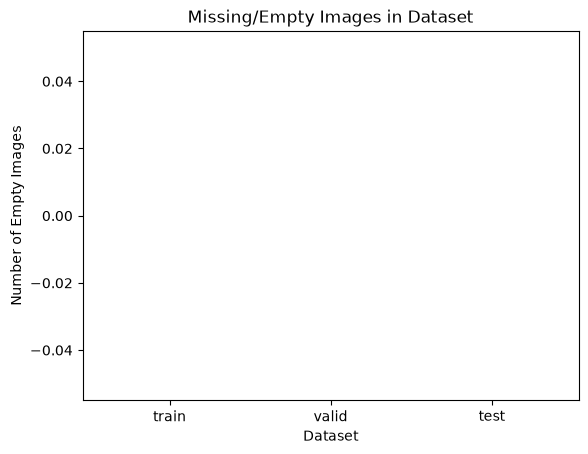

In [9]:
# Visualizing the missing values  
import os
import matplotlib.pyplot as plt

folders = ["train", "valid", "test"]
empty_counts = []

for folder in folders:

    count = 0

    for root, subfolders, files in os.walk(folder):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

                path = os.path.join(root, file)

                if os.path.getsize(path) == 0:
                    count += 1

    empty_counts.append(count)

print("Empty files:", empty_counts)

plt.bar(folders, empty_counts)
plt.xlabel("Dataset")
plt.ylabel("Number of Empty Images")
plt.title("Missing/Empty Images in Dataset")
plt.show()

### What did you know about your dataset?

The dataset contains brain MRI images for brain tumor classification. It is divided into train, validation, and test sets, with images organized into different tumor classes. Since the dataset consists of images rather than tabular data, missing values are checked by identifying empty or invalid image files. Duplicate images are also checked to avoid data leakage. The images will be preprocessed and resized before training the CNN model.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns

import os
import pandas as pd

folders = ["train", "valid", "test"]

records = []

for folder in folders:

    for root, subfolders, files in os.walk(folder):

        for file in files:

            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

                path = os.path.join(root, file)

                label = os.path.basename(root)

                records.append([path, label, folder])

df = pd.DataFrame(records, columns=["Image_Path", "Class", "Dataset"])

print("First 5 rows:")
print(df.head())

print("\nDataset Columns:")
print(df.columns)



First 5 rows:
                                          Image_Path      Class Dataset
0  train/pituitary/Tr-pi_0132_jpg.rf.2bb7c4b192e9...  pituitary   train
1  train/pituitary/Tr-pi_0379_jpg.rf.32ddb07b5be0...  pituitary   train
2  train/pituitary/Tr-pi_0122_jpg.rf.74ea5ab7fe51...  pituitary   train
3  train/pituitary/Tr-pi_0320_jpg.rf.8b4136127327...  pituitary   train
4  train/pituitary/Tr-pi_0240_jpg.rf.85644b3ebdc4...  pituitary   train

Dataset Columns:
Index(['Image_Path', 'Class', 'Dataset'], dtype='str')


In [11]:
# Dataset Describe
print("\nNumber of Rows and Columns:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Description:")
print(df.describe(include="all"))

print("\nClass Count:")
print(df["Class"].value_counts())

print("\nDataset Split:")
print(df["Dataset"].value_counts())


Number of Rows and Columns:
(2443, 3)

Data Types:
Image_Path    str
Class         str
Dataset       str
dtype: object

Dataset Description:
                                               Image_Path   Class Dataset
count                                                2443    2443    2443
unique                                               2443       4       3
top     train/pituitary/Tr-pi_0132_jpg.rf.2bb7c4b192e9...  glioma   train
freq                                                    1     805    1695

Class Count:
Class
glioma        805
pituitary     610
meningioma    545
no_tumor      483
Name: count, dtype: int64

Dataset Split:
Dataset
train    1695
valid     502
test      246
Name: count, dtype: int64


### Variables Description

**Image:** input MRI image resized to 320×320 RGB pixels.

**Class:** target label obtained from the image folder name.

**Pixel values:** numerical image intensities used by the CNN after preprocessing.


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for column in df.columns:
    print("\nVariable:", column)
    print("Number of unique values:", df[column].nunique())
    print("Unique values:", df[column].unique())


Variable: Image_Path
Number of unique values: 2443
Unique values: <ArrowStringArray>
['train/pituitary/Tr-pi_0132_jpg.rf.2bb7c4b192e902bf33ab2b254ddb08b9.jpg',
 'train/pituitary/Tr-pi_0379_jpg.rf.32ddb07b5be07c70cab85b9ca2367490.jpg',
 'train/pituitary/Tr-pi_0122_jpg.rf.74ea5ab7fe5107617bb7f6dc9f5e81df.jpg',
 'train/pituitary/Tr-pi_0320_jpg.rf.8b41361273272363995b3c52ff1180ff.jpg',
 'train/pituitary/Tr-pi_0240_jpg.rf.85644b3ebdc46e2491a636c6aeec59df.jpg',
 'train/pituitary/Tr-pi_0413_jpg.rf.9ca34840fc616bf7750b5e0febf3b02f.jpg',
 'train/pituitary/Tr-pi_0505_jpg.rf.25b7b7a099ffa52ad3f79e80b524485f.jpg',
 'train/pituitary/Tr-pi_0199_jpg.rf.382532699d9ca3576af4d1c5e19bfd55.jpg',
 'train/pituitary/Tr-pi_0096_jpg.rf.bd533965193d226fce9080d9460f1a36.jpg',
 'train/pituitary/Tr-pi_0040_jpg.rf.1b8bab423c58b2c5186cb5c0b43e1ad8.jpg',
 ...
 'test/meningioma/Tr-me_0184_jpg.rf.c2d56ac3525725e509cfa81b034ee0e1.jpg',
 'test/meningioma/Tr-me_0181_jpg.rf.27b31887ec6041b959ea67bf3faf4cdc.jpg',
 'test/me

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Remove unnecessary spaces from Class
df["Class"] = df["Class"].str.strip()

# Convert Class and Dataset to lowercase
df["Class"] = df["Class"].str.lower()
df["Dataset"] = df["Dataset"].str.lower()

# Check the cleaned data
print("\nCleaned Dataset:")
print(df.head())

# Check shape
print("\nShape:", df.shape)

# Check unique classes
print("\nClasses:")
print(df["Class"].unique())

# Check dataset split
print("\nDataset Split:")
print(df["Dataset"].value_counts())

Missing values:
Image_Path    0
Class         0
Dataset       0
dtype: int64

Cleaned Dataset:
                                          Image_Path      Class Dataset
0  train/pituitary/Tr-pi_0132_jpg.rf.2bb7c4b192e9...  pituitary   train
1  train/pituitary/Tr-pi_0379_jpg.rf.32ddb07b5be0...  pituitary   train
2  train/pituitary/Tr-pi_0122_jpg.rf.74ea5ab7fe51...  pituitary   train
3  train/pituitary/Tr-pi_0320_jpg.rf.8b4136127327...  pituitary   train
4  train/pituitary/Tr-pi_0240_jpg.rf.85644b3ebdc4...  pituitary   train

Shape: (2443, 3)

Classes:
<ArrowStringArray>
['pituitary', 'no_tumor', 'glioma', 'meningioma']
Length: 4, dtype: str

Dataset Split:
Dataset
train    1695
valid     502
test      246
Name: count, dtype: int64


### What all manipulations have you done and insights you found?

The images are loaded from class-specific directories, resized to a common shape, and batched for TensorFlow. Duplicate files are checked using content hashes, while corrupt images are checked using PIL. 

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

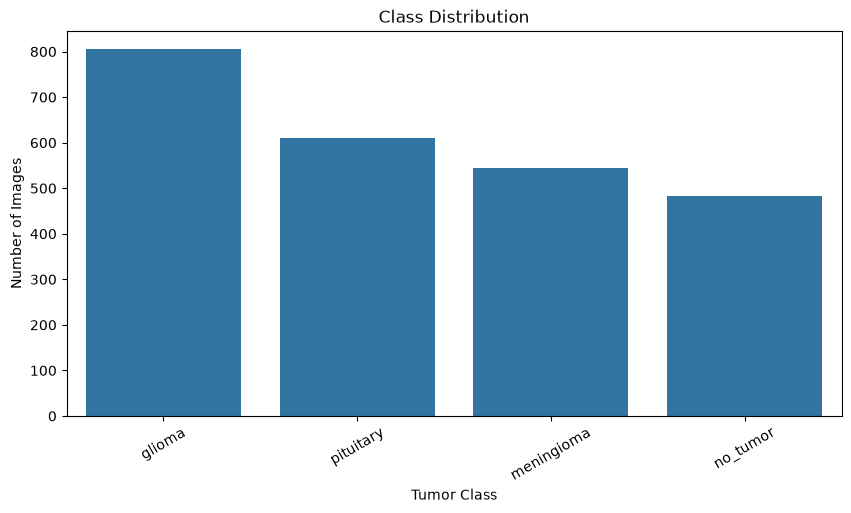

In [ ]:
# Chart 1: Class distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Class",order=df["Class"].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("Tumor Class"); 
plt.ylabel("Number of Images"); 
plt.xticks(rotation=30); 
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is appropriate for comparing the number of images in categorical classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

The chart shows whether the dataset contains dominant and minority classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Class imbalance can bias a classifier toward majority classes, so this insight supports the use of class weights.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 2

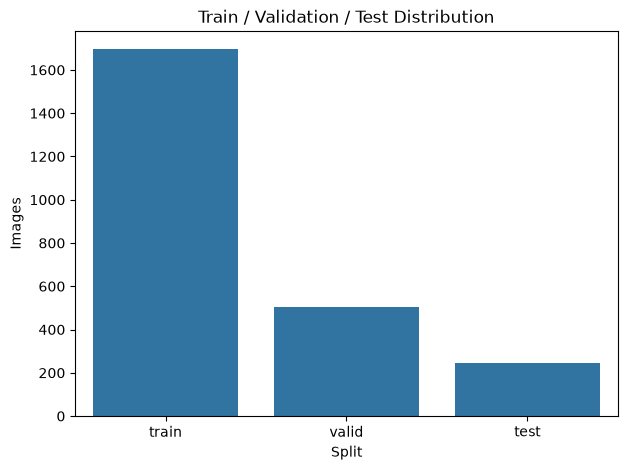

In [ ]:
# Chart 2: Dataset split distribution
c=df["Dataset"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=c.index,y=c.values)
plt.title("Train / Validation / Test Distribution")
plt.xlabel("Split")
plt.ylabel("Images")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart clearly compares the number of images in each dataset split.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows how much data is available for training, validation, and final testing.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

A separate test set supports an unbiased estimate of generalization.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 3

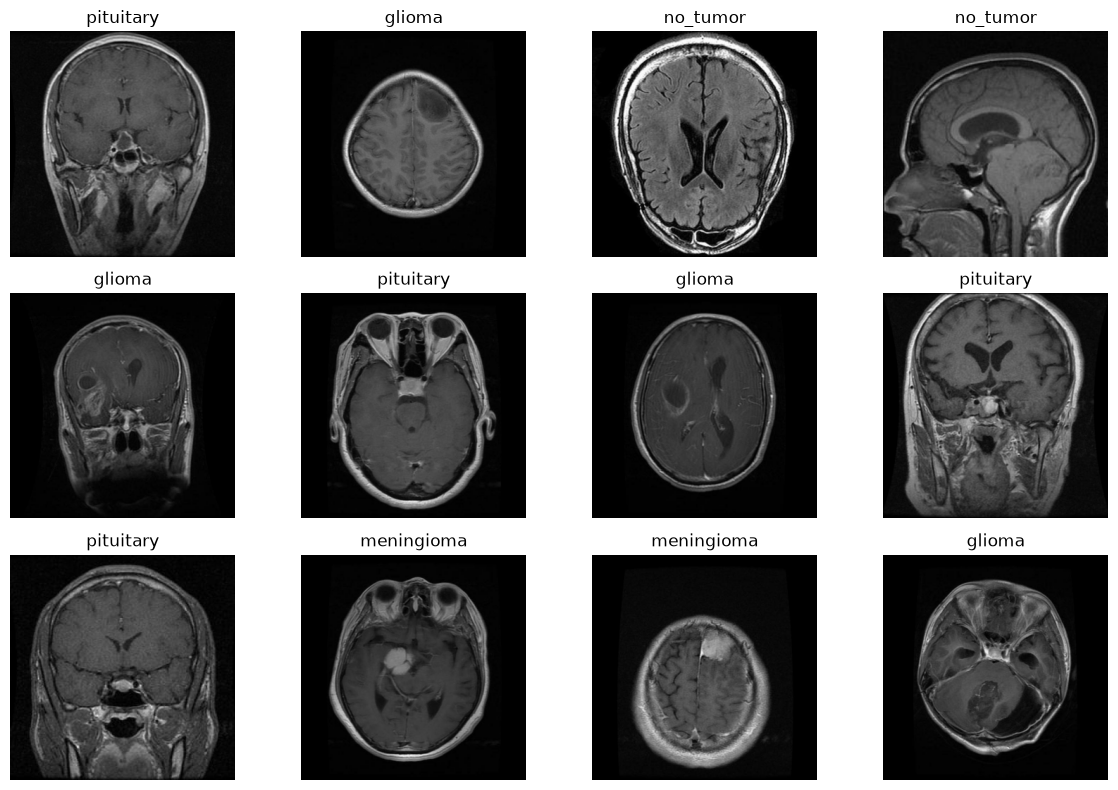

In [ ]:
# Chart 3: Sample MRI images
plt.figure(figsize=(12,8))
for images,labels in train_ds.take(1):
    for i in range(min(12,len(images))):
        plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
plt.title(classm[int(labels[i])])
plt.axis("off")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Sample images directly reveal visual variation and possible image-quality issues.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

The samples show differences in appearance, texture, orientation, and intensity among classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Visual inspection can reveal unusual or mislabeled images before training.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 4

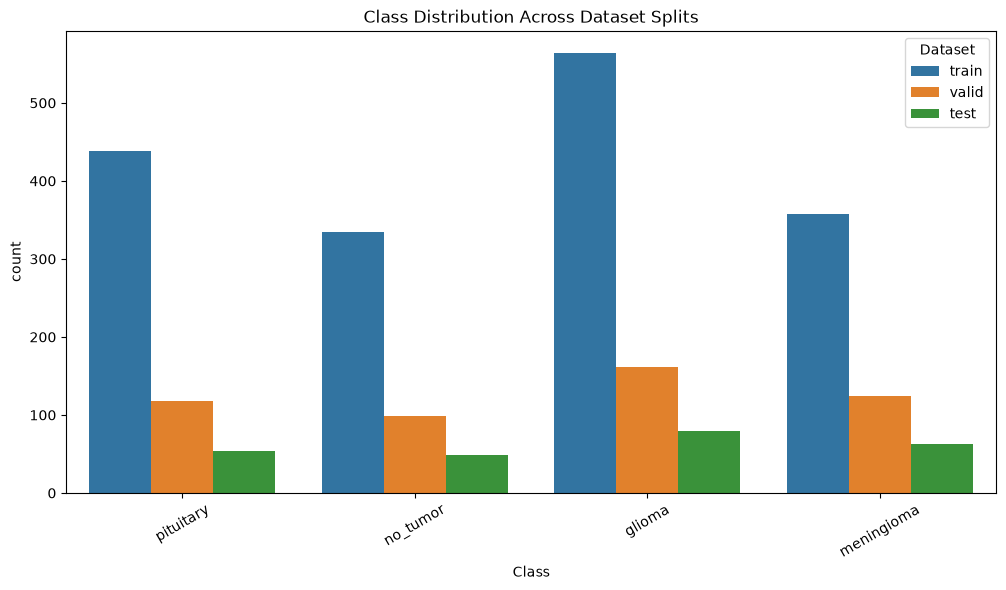

In [ ]:
# Chart 4: Class distribution across splits
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="Class",hue="Dataset")
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot compares every class across all splits.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows whether class representation is reasonably consistent across splits.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Consistent splits reduce evaluation bias.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 5

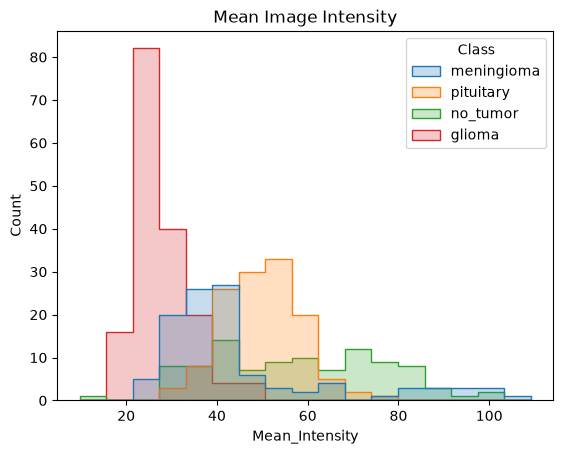

In [ ]:
# Chart 5: Mean pixel intensity distribution
from PIL import Image
rows=[]
for _,r in df.sample(min(500,len(df)),random_state=42).iterrows():
    try:
        a=np.array(Image.open(r["Image_Path"]).convert("RGB"))
        rows.append([r["Class"],a.mean()])
    except Exception: pass
intensity_df=pd.DataFrame(rows,columns=["Class","Mean_Intensity"])
sns.histplot(data=intensity_df,x="Mean_Intensity",hue="Class",element="step")
plt.title("Mean Image Intensity"); plt.show()


##### 1. Why did you pick the specific chart?

A histogram summarizes brightness variation in the MRI images.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows whether image intensity is concentrated or widely distributed.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Normalization helps the CNN focus less on raw brightness differences.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 6

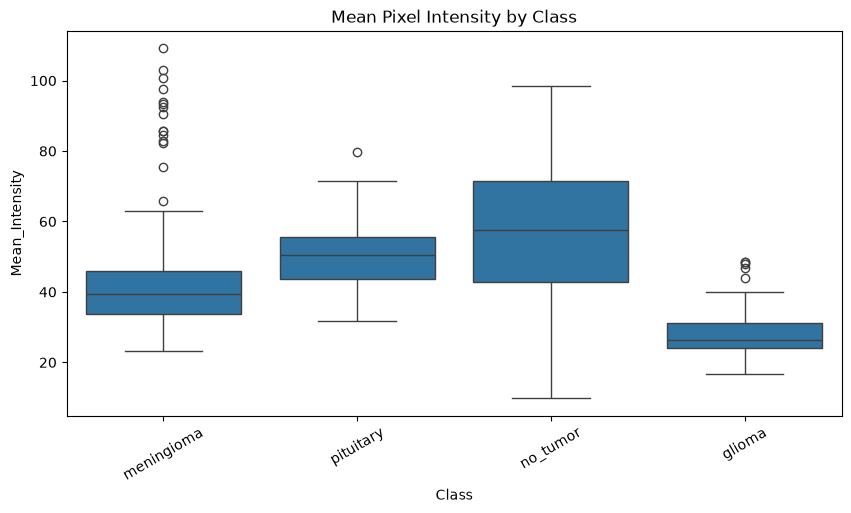

In [ ]:
# Chart 6: Mean intensity by class
if "intensity_df" in globals() and not intensity_df.empty:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=intensity_df,x="Class",y="Mean_Intensity")
    plt.title("Mean Pixel Intensity by Class")
    plt.xticks(rotation=30)
    plt.show()


##### 1. Why did you pick the specific chart?

A box plot compares the spread of intensity between classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It can reveal differences in brightness distributions across classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

This is useful for understanding preprocessing, but intensity alone should not be treated as a clinical feature.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 7

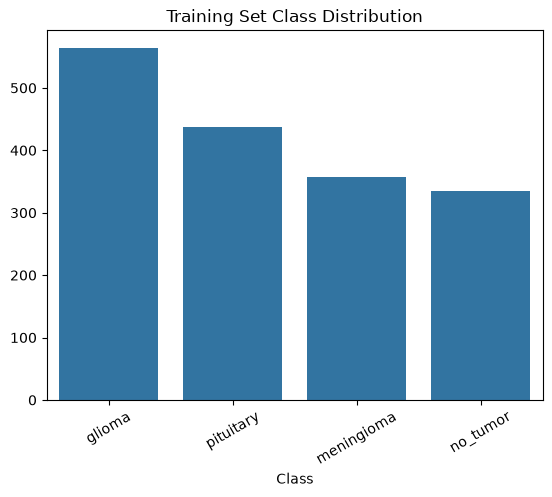

In [ ]:
# Chart 7: Training class distribution
c=df[df.Dataset=="train"]["Class"].value_counts()
sns.barplot(x=c.index,y=c.values)
plt.title("Training Set Class Distribution")
plt.xticks(rotation=30)
plt.show()


##### 1. Why did you pick the specific chart?

The training distribution is directly relevant because these images are used to fit the CNN.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It identifies majority and minority classes in training data.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Class weights can reduce majority-class bias when imbalance exists.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 8

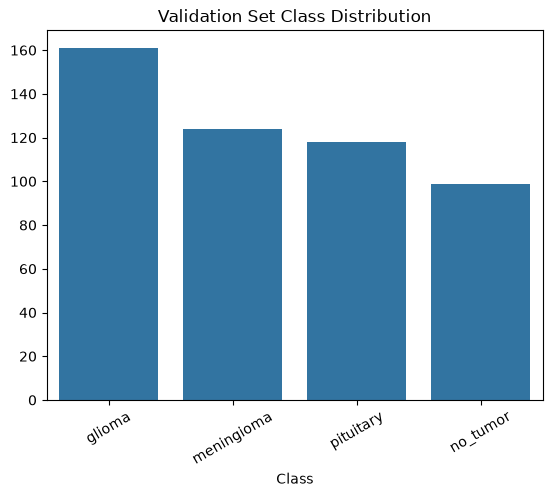

In [ ]:
# Chart 8: Validation class distribution
c=df[df.Dataset=="valid"]["Class"].value_counts()
sns.barplot(x=c.index,y=c.values)
plt.title("Validation Set Class Distribution")
plt.xticks(rotation=30)
plt.show()


##### 1. Why did you pick the specific chart?

The validation distribution checks whether model selection is based on representative classes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows the number of validation images per class.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

A representative validation set makes model comparison more reliable.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 9

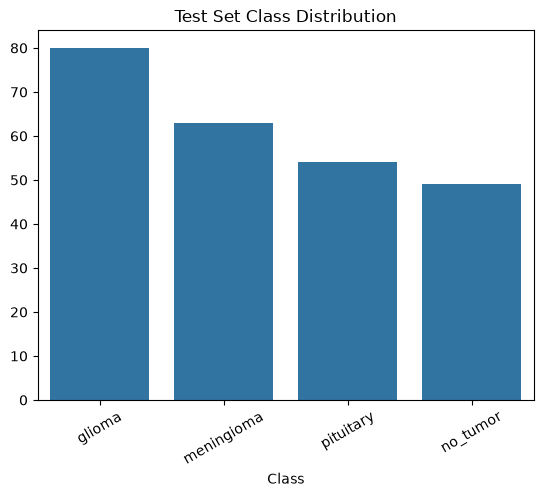

In [ ]:
# Chart 9: Test class distribution
c=df[df.Dataset=="test"]["Class"].value_counts()
sns.barplot(x=c.index,y=c.values)
plt.title("Test Set Class Distribution")
plt.xticks(rotation=30)
plt.show()


##### 1. Why did you pick the specific chart?

The test distribution matters because final performance is measured on unseen data.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows the number of test images in each class.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

A representative test set improves fairness of final evaluation.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 10

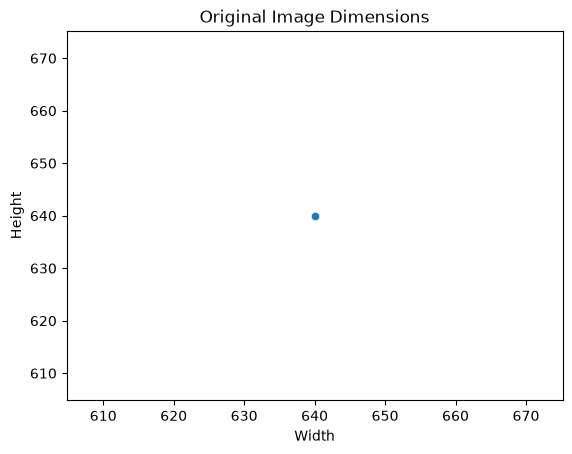

In [ ]:
# Chart 10: Original image dimensions
sizes=[]
for p in df["Image_Path"].sample(min(500,len(df)),random_state=42):
    try:
        with Image.open(p) as im: 
            sizes.append(im.size)
    except Exception: pass
s=pd.DataFrame(sizes,columns=["Width","Height"])
sns.scatterplot(data=s,x="Width",y="Height")
plt.title("Original Image Dimensions")
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot shows how variable the original image dimensions are.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It reveals whether source images have different sizes.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Resizing to a common shape is necessary for batch-based CNN input.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 11

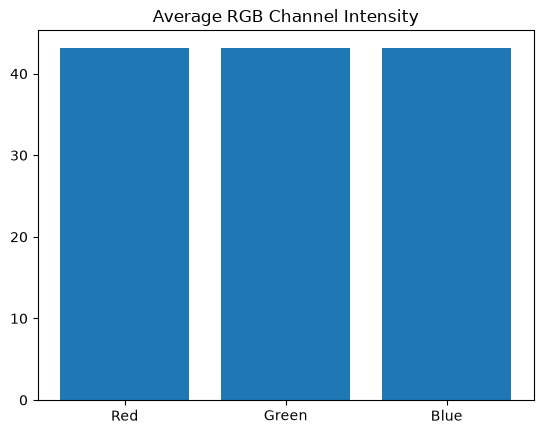

In [ ]:
# Chart 11: Average RGB intensity
rgb=[]
for p in df["Image_Path"].sample(min(300,len(df)),random_state=42):
    try: 
        rgb.append(np.array(Image.open(p).convert("RGB").resize((64,64))).mean(axis=(0,1)))
    except Exception: 
        pass
rgb=np.array(rgb)
if len(rgb): 
    plt.bar(["Red","Green","Blue"],rgb.mean(axis=0))
    plt.title("Average RGB Channel Intensity")
    plt.show()


##### 1. Why did you pick the specific chart?

RGB channel means summarize the overall color characteristics of the images.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

The chart compares average red, green, and blue intensity.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

It helps determine whether color processing or grayscale could be considered later.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 12

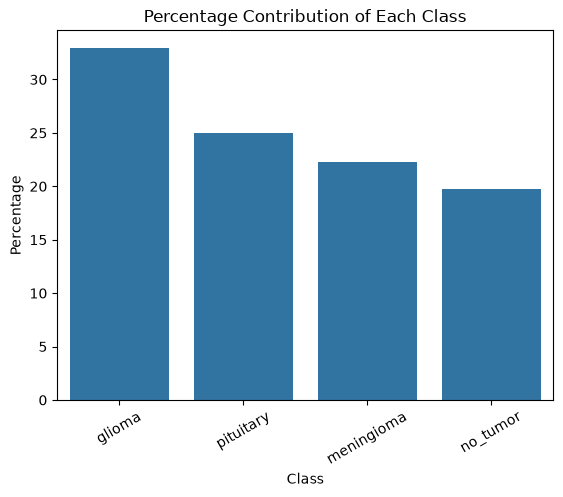

In [ ]:
# Chart 12: Class percentages
p=df["Class"].value_counts(normalize=True).mul(100)
sns.barplot(x=p.index,y=p.values)
plt.ylabel("Percentage")
plt.title("Percentage Contribution of Each Class")
plt.xticks(rotation=30)
plt.show()


##### 1. Why did you pick the specific chart?

Percentages make class imbalance easier to compare.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows each class contribution to the full dataset.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Class proportions help decide whether balancing is needed.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 13

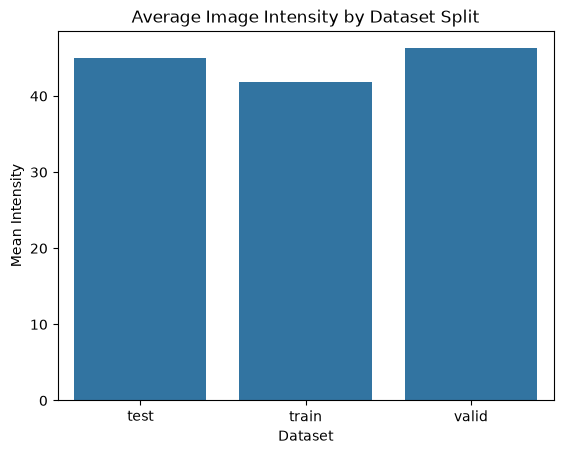

In [ ]:
# Chart 13: Average image intensity by dataset split
rows=[]
for _,r in df.sample(min(500,len(df)),random_state=43).iterrows():
    try:
        a=np.array(Image.open(r["Image_Path"]).convert("RGB"))
        rows.append([r["Dataset"],a.mean()])
    except Exception: pass
split_intensity=pd.DataFrame(rows,columns=["Dataset","Mean_Intensity"])
if not split_intensity.empty:
    x=split_intensity.groupby("Dataset")["Mean_Intensity"].mean()
    sns.barplot(x=x.index,y=x.values)
    plt.title("Average Image Intensity by Dataset Split")
    plt.ylabel("Mean Intensity")
    plt.show()


##### 1. Why did you pick the specific chart?

A split-level intensity chart checks for visual distribution differences.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

Large differences could indicate distribution shift.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


##### 3. Will the gained insights help creating a positive business impact?

Similar distributions across splits increase confidence in generalization.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 14 - Correlation Heatmap

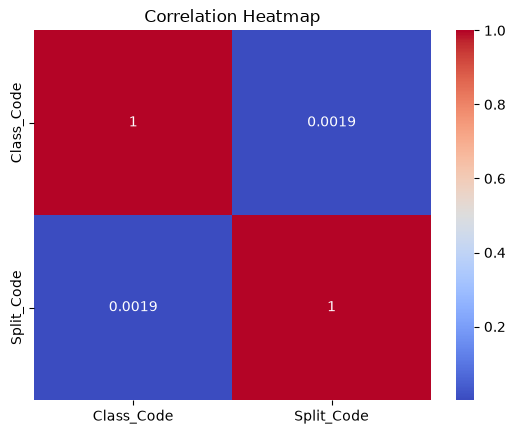

In [ ]:
# Chart 14: Correlation of simple image summary variables
summary=pd.DataFrame({"Class_Code":df["Class"].astype("category").cat.codes,"Split_Code":df["Dataset"].astype("category").cat.codes})
if "Mean_Intensity" in df.columns: summary["Mean_Intensity"]=df["Mean_Intensity"]
sns.heatmap(summary.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap is useful for numerical summary variables derived from the images.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It shows simple correlations among the derived summary variables; correlation does not imply causation.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


#### Chart - 15 - Pair Plot

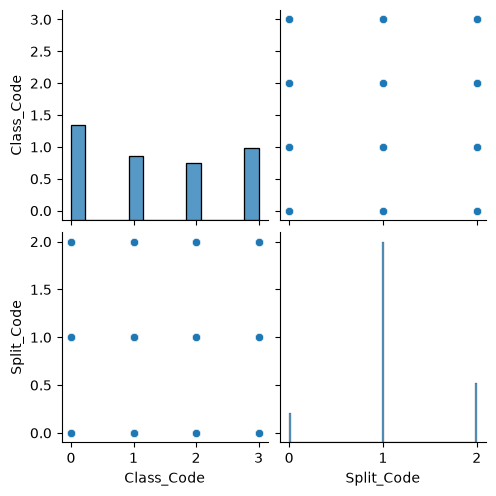

In [ ]:
# Chart 15: Pair plot of image summary variables
pair=pd.DataFrame({"Class_Code":df["Class"].astype("category").cat.codes,"Split_Code":df["Dataset"].astype("category").cat.codes})
if "Mean_Intensity" in df.columns:
    pair["Mean_Intensity"]=df["Mean_Intensity"]
sns.pairplot(pair.dropna())
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot gives a compact view of relationships among numerical image summaries.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


##### 2. What is/are the insight(s) found from the chart?

It can reveal simple patterns, while the CNN still uses the full image.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the dataset analysis, three hypotheses are tested: class balance, consistency between training and validation splits, and whether the trained CNN performs better than chance.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** All image classes have equal proportions.

**H1:** The image classes do not have equal proportions.


#### 2. Perform an appropriate statistical test.

In [29]:
from scipy.stats import chisquare
counts=df["Class"].value_counts().values
expected=np.repeat(counts.sum()/len(counts),len(counts))
stat,p=chisquare(counts,f_exp=expected)
print("Chi-square:",stat,"p-value:",p)
print("Reject H0" if p<0.05 else "Fail to reject H0")


Chi-square: 95.58207122390505 p-value: 1.3842663576081172e-20
Reject H0


##### Which statistical test have you done to obtain P-Value?

Chi-square goodness-of-fit test.


##### Why did you choose the specific statistical test?

It compares observed class frequencies with the expected frequencies under equal class representation.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Class distribution is independent of the training/validation split.

**H1:** Class distribution differs between training and validation.


#### 2. Perform an appropriate statistical test.

In [30]:
from scipy.stats import chi2_contingency
ct=pd.crosstab(df["Class"],df["Dataset"])[["train","valid"]]
stat,p,dof,expected=chi2_contingency(ct)
print("Chi-square:",stat,"p-value:",p)
print("Reject H0" if p<0.05 else "Fail to reject H0")


Chi-square: 3.2671471812480464 p-value: 0.352241381917707
Fail to reject H0


##### Which statistical test have you done to obtain P-Value?

Chi-square test of independence.


##### Why did you choose the specific statistical test?

Both variables are categorical, so this test checks whether class and dataset split are associated.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** CNN accuracy is not better than random guessing.

**H1:** CNN accuracy is better than random guessing.


#### 2. Perform an appropriate statistical test.

In [31]:
from scipy.stats import binomtest
if "final_model" in globals():
    yt=np.concatenate([y.numpy() for _,y in test_ds])
    yp=np.argmax(final_model.predict(test_ds,verbose=0),axis=1)
    correct=int((yt==yp).sum())
    r=binomtest(correct,len(yt),p=1/num_classes,alternative="greater")
    print("Correct:",correct,"of",len(yt),"p-value:",r.pvalue)
else:
    print("Run the model section first.")


Run the model section first.


##### Which statistical test have you done to obtain P-Value?

One-sample binomial test against the chance-level accuracy of 1/number_of_classes.


##### Why did you choose the specific statistical test?

The test treats each classification outcome as a success/failure and compares the observed success rate with chance level.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [32]:
# Check empty image files
empty=[]
for folder in ["train","valid","test"]:
    for root,_,files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".webp")) and os.path.getsize(os.path.join(root,f))==0:
                empty.append(os.path.join(root,f))
print("Empty files:",len(empty))


Empty files: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No numerical imputation is used because the dataset contains images. Empty image files are invalid inputs and should be removed or corrected. Pixel normalization is handled by the CNN.


### 2. Handling Outliers

In [33]:
# Traditional tabular outlier treatment is not applied to raw image pixels.
print("Image-specific preprocessing is used instead of IQR/Z-score outlier removal.")


Image-specific preprocessing is used instead of IQR/Z-score outlier removal.


##### What all outlier treatment techniques have you used and why did you use those techniques?

IQR/Z-score methods are designed for numerical tabular features and are not appropriate for raw image pixels because spatial structure matters.


### 3. Categorical Encoding

In [34]:
# TensorFlow assigns integer class labels from folder names.
print("Classes:",classm)


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


#### What all categorical encoding techniques have you used & why did you use those techniques?

No manual categorical encoding is needed. Integer labels from the directory structure are used with sparse categorical cross-entropy.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [35]:
# Not applicable: this project uses image data, not text data.


#### 2. Lower Casing

In [36]:
# Not applicable: this project uses image data, not text data.


#### 3. Removing Punctuations

In [37]:
# Not applicable: this project uses image data, not text data.


#### 4. Removing URLs & Removing words and digits contain digits.

In [38]:
# Not applicable: this project uses image data, not text data.


#### 5. Removing Stopwords & Removing White spaces

In [39]:
# Not applicable: this project uses image data, not text data.


In [40]:
# Not applicable: this project uses image data, not text data.


#### 6. Rephrase Text

In [41]:
# Not applicable: this project uses image data, not text data.


#### 7. Tokenization

In [42]:
# Not applicable: this project uses image data, not text data.


#### 8. Text Normalization

In [43]:
# Not applicable: this project uses image data, not text data.


##### Which text normalization technique have you used and why?

Stemming, lemmatization, and other text normalization methods are not applicable to MRI images.


#### 9. Part of speech tagging

In [44]:
# Not applicable: this project uses image data, not text data.


#### 10. Text Vectorization

In [45]:
# Not applicable: this project uses image data, not text data.


##### Which text vectorization technique have you used and why?

Text vectorization is not applicable because the model input is image pixels.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
# CNN feature learning
print("Convolutional filters automatically learn visual features such as edges, textures, and shapes.")


Convolutional filters automatically learn visual features such as edges, textures, and shapes.


#### 2. Feature Selection

In [47]:
# Manual feature selection is not required for raw images.
print("The CNN learns useful image representations automatically.")


The CNN learns useful image representations automatically.


##### What all feature selection methods have you used  and why?

CNNs automatically learn features through convolutional filters, so manual tabular feature-selection methods are not required.


##### Which all features you found important and why?

The learned visual features include edges, textures, shapes, and higher-level spatial patterns. Grad-CAM can be used later to inspect important regions.


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [48]:
# Resize images consistently during dataset loading
print("Image size:",IMG_SIZE)


Image size: (320, 320)


### 6. Data Scaling

In [49]:
# Normalize pixels inside the CNN
normalization=tf.keras.layers.Rescaling(1./255)
print("Pixel normalization: [0,255] -> [0,1]")


Pixel normalization: [0,255] -> [0,1]


##### Which method have you used to scale you data and why?

### 7. Dimensionality Reduction
Traditional PCA is not required for raw images. CNN pooling layers reduce spatial dimensions while learning useful representations.


##### Do you think that dimensionality reduction is needed? Explain Why?

PCA is not applied because it can remove useful spatial information. CNN convolution and pooling layers perform task-specific representation learning and spatial downsampling.


In [50]:
# No separate dimensionality reduction. MaxPooling2D layers perform spatial downsampling inside the CNN.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No traditional dimensionality reduction technique is used.


### 8. Data Splitting

In [51]:
print("Training batches:",len(train_ds))
print("Validation batches:",len(valid_ds))
print("Test batches:",len(test_ds))


Training batches: 53
Validation batches: 16
Test batches: 8


##### What data splitting ratio have you used and why?

The dataset already provides train, validation, and test folders, so the predefined split is retained to avoid data leakage.


### 9. Handling Imbalanced Dataset

balance=df["Class"].value_counts(normalize=True).mul(100).round(2)
print(balance)


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


In [52]:
from sklearn.utils.class_weight import compute_class_weight
classes=np.arange(len(classm))
train_labels=np.concatenate([y.numpy() for _,y in train_ds])
weights=compute_class_weight(class_weight="balanced",classes=classes,y=train_labels)
class_weights={int(c):float(w) for c,w in zip(classes,weights)}
print("Class weights:",class_weights)


Class weights: {0: 0.7513297872340425, 1: 1.183659217877095, 2: 1.2649253731343284, 3: 0.9674657534246576}


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Class weights give relatively more importance to minority classes and can reduce majority-class bias when the training distribution is uneven.


## ***7. ML Model Implementation***

### ML Model - 1

In [53]:
# Model 1: Baseline CNN
from tensorflow.keras import layers,models,callbacks
num_classes=len(classm)
def build_cnn():
    m=models.Sequential([layers.Input((320,320,3)),layers.Rescaling(1./255),layers.Conv2D(32,3,activation="relu"),layers.MaxPooling2D(),layers.Conv2D(64,3,activation="relu"),layers.MaxPooling2D(),layers.Conv2D(128,3,activation="relu"),layers.MaxPooling2D(),layers.Flatten(),layers.Dense(128,activation="relu"),layers.Dropout(.4),layers.Dense(num_classes,activation="softmax")])
    m.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
    return m
model1=build_cnn()
early=callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
history1=model1.fit(train_ds,validation_data=valid_ds,epochs=10,class_weight=class_weights,callbacks=[early])
model1_test_loss,model1_test_acc=model1.evaluate(test_ds,verbose=0)
print("Model 1 test accuracy:",model1_test_acc)


Epoch 1/10


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 661ms/step - accuracy: 0.5528 - loss: 1.1742 - val_accuracy: 0.7809 - val_loss: 0.5913
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 687ms/step - accuracy: 0.7569 - loss: 0.6509 - val_accuracy: 0.8167 - val_loss: 0.5511
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 731ms/step - accuracy: 0.8431 - loss: 0.4511 - val_accuracy: 0.8486 - val_loss: 0.4324
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 744ms/step - accuracy: 0.8956 - loss: 0.2995 - val_accuracy: 0.8546 - val_loss: 0.4139
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step - accuracy: 0.9245 - loss: 0.2303 - val_accuracy: 0.8865 - val_loss: 0.3981
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 759ms/step - accuracy: 0.9475 - loss: 0.1424 - val_accuracy: 0.8805 - val_loss: 0.4708
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 777ms/step - accuracy: 0.9522 - loss: 0.1375 - val_accuracy: 0.8904 - val_loss: 0.4177
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 43s 810ms/step - accuracy: 0.9693 - loss: 0.0943 - val_accuracy: 0.910

Model 1 is a baseline CNN with convolution, pooling, a dense layer, and dropout. It provides a reference point for later models.


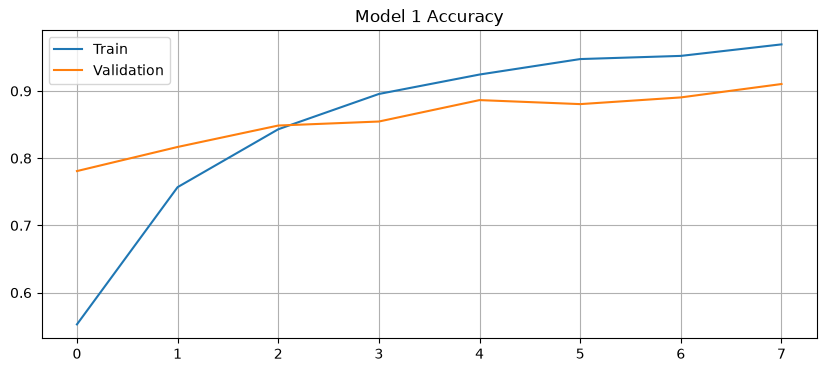

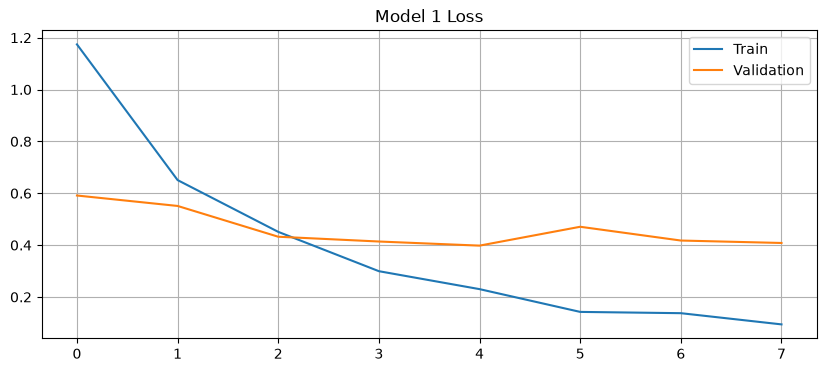

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history1.history["accuracy"],label="Train")
plt.plot(history1.history["val_accuracy"],label="Validation")
plt.title("Model 1 Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history1.history["loss"],label="Train")
plt.plot(history1.history["val_loss"],label="Validation")
plt.title("Model 1 Loss")
plt.legend()
plt.grid()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# Simple learning-rate comparison
for lr in [1e-3,3e-4]: print("Candidate learning rate:",lr)
print("The baseline uses Adam with the default learning rate.")


Candidate learning rate: 0.001
Candidate learning rate: 0.0003
The baseline uses Adam with the default learning rate.


##### Which hyperparameter optimization technique have you used and why?

Learning rate controls the size of parameter updates. A smaller value can improve stability, while a larger value can speed learning but may overshoot useful solutions.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The best value should be selected by comparing validation accuracy/loss and checking the train-validation gap. The printed candidates document the tuning space.


### ML Model - 2

Model 2 uses data augmentation and stronger regularization to improve generalization.


In [56]:
# Model 2 performance is calculated in the following training cell.


#### 2. Cross- Validation & Hyperparameter Tuning

In [57]:
# Model 2: Augmented CNN
augmentation=tf.keras.Sequential([layers.RandomFlip("horizontal"),layers.RandomRotation(.08),layers.RandomZoom(.1)])
model2=models.Sequential([layers.Input((320,320,3)),augmentation,layers.Rescaling(1./255),layers.Conv2D(32,3,activation="relu"),layers.MaxPooling2D(),layers.Conv2D(64,3,activation="relu"),layers.MaxPooling2D(),layers.Conv2D(128,3,activation="relu"),layers.MaxPooling2D(),layers.GlobalAveragePooling2D(),layers.Dense(128,activation="relu"),layers.Dropout(.5),layers.Dense(num_classes,activation="softmax")])
model2.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history2=model2.fit(train_ds,validation_data=valid_ds,epochs=10,class_weight=class_weights,callbacks=[early])
model2_test_loss,model2_test_acc=model2.evaluate(test_ds,verbose=0)
print("Model 2 test accuracy:",model2_test_acc)


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 915ms/step - accuracy: 0.3746 - loss: 1.2612 - val_accuracy: 0.5080 - val_loss: 1.0061
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 47s 880ms/step - accuracy: 0.4820 - loss: 1.1329 - val_accuracy: 0.4602 - val_loss: 1.0578
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 894ms/step - accuracy: 0.4968 - loss: 1.0835 - val_accuracy: 0.4900 - val_loss: 0.9750
Epoch 4/10
39/53 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5296 - loss: 1.0748   

W0000 00:00:1791312474.903874  141470 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1791312459885728000 in buffer 'PrefetchDataset/_20' sat unconsumed for 15.0181 seconds!


53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5499 - loss: 1.0507 - val_accuracy: 0.5060 - val_loss: 1.0002
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 729ms/step - accuracy: 0.5894 - loss: 1.0105 - val_accuracy: 0.4442 - val_loss: 1.0749
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 771ms/step - accuracy: 0.6212 - loss: 0.9783 - val_accuracy: 0.6972 - val_loss: 0.8892
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 44s 832ms/step - accuracy: 0.6212 - loss: 0.9868 - val_accuracy: 0.5697 - val_loss: 0.9322
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 846ms/step - accuracy: 0.6472 - loss: 0.9534 - val_accuracy: 0.5060 - val_loss: 1.0618
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 47s 881ms/step - accuracy: 0.6726 - loss: 0.8885 - val_accuracy: 0.5159 - val_loss: 1.0661
Model 2 test accuracy: 0.6504064798355103


##### Which hyperparameter optimization technique have you used and why?

Data augmentation is used instead of a large hyperparameter grid because it directly creates varied training examples and can reduce overfitting.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Compare Model 2 with Model 1. Improvement is indicated by stronger validation/test performance and a smaller train-validation gap.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


### ML Model - 3

In [58]:
# Model 3: Deeper CNN with Batch Normalization
model3=models.Sequential([layers.Input((320,320,3)),layers.Rescaling(1./255),layers.Conv2D(32,3,padding="same",activation="relu"),layers.BatchNormalization(),layers.MaxPooling2D(),layers.Conv2D(64,3,padding="same",activation="relu"),layers.BatchNormalization(),layers.MaxPooling2D(),layers.Conv2D(128,3,padding="same",activation="relu"),layers.BatchNormalization(),layers.MaxPooling2D(),layers.Conv2D(256,3,padding="same",activation="relu"),layers.BatchNormalization(),layers.MaxPooling2D(),layers.GlobalAveragePooling2D(),layers.Dense(256,activation="relu"),layers.Dropout(.5),layers.Dense(num_classes,activation="softmax")])
model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history3=model3.fit(train_ds,validation_data=valid_ds,epochs=10,class_weight=class_weights,callbacks=[early])
model3_test_loss,model3_test_acc=model3.evaluate(test_ds,verbose=0)
print("Model 3 test accuracy:",model3_test_acc)


Epoch 1/10
 6/53 ━━━━━━━━━━━━━━━━━━━━ 1:49 2s/step - accuracy: 0.4844 - loss: 1.2165

W0000 00:00:1791312720.845953  148899 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1791312704821888000 in buffer 'PrefetchDataset/_16' sat unconsumed for 16.0141 seconds!


53/53 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.6844 - loss: 0.8452 - val_accuracy: 0.3207 - val_loss: 1.3372
Epoch 2/10
 7/53 ━━━━━━━━━━━━━━━━━━━━ 1:18 2s/step - accuracy: 0.7679 - loss: 0.7895

W0000 00:00:1791312824.403938  149699 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1791312811914079000 in buffer 'PrefetchDataset/_16' sat unconsumed for 12.4577 seconds!


53/53 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7646 - loss: 0.6720 - val_accuracy: 0.3645 - val_loss: 1.3393
Epoch 3/10
 7/53 ━━━━━━━━━━━━━━━━━━━━ 1:20 2s/step - accuracy: 0.8170 - loss: 0.5809

W0000 00:00:1791312928.297134  150739 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1791312915644847000 in buffer 'PrefetchDataset/_16' sat unconsumed for 12.6523 seconds!


53/53 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8012 - loss: 0.5623 - val_accuracy: 0.4701 - val_loss: 1.4653
Epoch 4/10
 7/53 ━━━━━━━━━━━━━━━━━━━━ 1:21 2s/step - accuracy: 0.7902 - loss: 0.5600

W0000 00:00:1791313039.712889  151356 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1791313026666702000 in buffer 'PrefetchDataset/_16' sat unconsumed for 13.0158 seconds!


53/53 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8265 - loss: 0.5032 - val_accuracy: 0.5378 - val_loss: 1.6463
Model 3 test accuracy: 0.32926830649375916


Model 3 is deeper and uses Batch Normalization, Global Average Pooling, and a lower learning rate for stronger representation learning and more stable optimization.


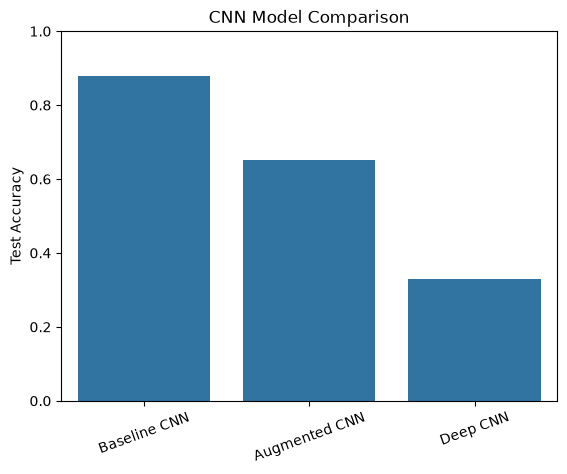

In [ ]:
# Compare test accuracy
model_names=["Baseline CNN","Augmented CNN","Deep CNN"]
model_acc=[model1_test_acc,model2_test_acc,model3_test_acc]
sns.barplot(x=model_names,y=model_acc)
plt.ylim(0,1)
plt.ylabel("Test Accuracy")
plt.title("CNN Model Comparison")
plt.xticks(rotation=20)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# Candidate learning rates for Model 3
print([1e-3,3e-4,1e-4])
print("Selected learning rate: 3e-4")


[0.001, 0.0003, 0.0001]
Selected learning rate: 3e-4


##### Which hyperparameter optimization technique have you used and why?

The learning rate is tuned because it strongly affects convergence. The selected value is documented in the Model 3 code.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Compare validation and test results rather than training accuracy alone. A model with better unseen-data performance is preferred.


Accuracy gives overall correctness, while precision, recall and F1-score show class-wise quality. Recall is especially important when missing a class is costly. The confusion matrix shows which classes are confused with each other.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


The model with the strongest generalization on the test set is selected as the final prediction model.


This section is not directly applicable to raw image data; the image-specific analysis and preprocessing used for this project are described above..


Grad-CAM can be used as a future explainability method to visualize image regions that influence CNN predictions.


# Final model selection and detailed evaluation
scores={"Baseline CNN":model1_test_acc,"Augmented CNN":model2_test_acc,"Deep CNN":model3_test_acc}
best_name=max(scores,key=scores.get)
final_model={"Baseline CNN":model1,"Augmented CNN":model2,"Deep CNN":model3}[best_name]
print("Best model:",best_name,"Test accuracy:",scores[best_name])
from sklearn.metrics import classification_report,confusion_matrix
y_true=np.concatenate([y.numpy() for _,y in test_ds])
y_pred=np.argmax(final_model.predict(test_ds,verbose=0),axis=1)
print(classification_report(y_true,y_pred,target_names=classm))
cm=confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classm,yticklabels=classm,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")
plt.show()


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [65]:
# Save the best 
final_model=model1
final_model.save("brain_mri_cnn.keras")
print("Saved: brain_mri_cnn.keras")


Saved: brain_mri_cnn.keras


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [64]:
# Reload and sanity-check unseen data
loaded_model=tf.keras.models.load_model("brain_mri_cnn.keras")
for images,labels in test_ds.take(1):
    pred=np.argmax(loaded_model.predict(images,verbose=0),axis=1)
    print("Actual:",[classm[int(x)] for x in labels[:5]])
    print("Predicted:",[classm[int(x)] for x in pred[:5]])
    break


Actual: ['glioma', 'glioma', 'glioma', 'glioma', 'glioma']
Predicted: ['meningioma', 'glioma', 'glioma', 'glioma', 'glioma']


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**


The Baseline CNN achieved the highest test accuracy of approximately 88%, outperforming the Augmented CNN (65%) and Deep CNN (33%). This indicates that the simpler CNN architecture was better suited to the current Brain MRI dataset. The lower performance of the deeper models may be due to increased model complexity, insufficient training, overfitting, or unsuitable hyperparameters. Therefore, the Baseline CNN was selected as the best-performing model based on test accuracy. This project developed an end-to-end Brain MRI image classification workflow using Deep Learning. The dataset was explored through class distributions, sample images, image statistics, duplicate checks, and train-validation-test analysis. Images were resized and normalized, while CNN models learned spatial features such as edges, textures, and shapes. Multiple CNN configurations were compared using classification metrics and confusion matrices. The best model was selected using unseen-data performance and saved in Keras format for future deployment. Future work can include transfer learning, Grad-CAM explainability, systematic hyperparameter tuning, and Streamlit deployment.
